# Ethiopia Food Prices — 08 FEATURE ENGINEERING

Builds a supervised-learning-ready feature matrix from the spike-flagged dataset (`04 SPIKE ANALYSIS`),
at **market × commodity_unit** series granularity. This is the hand-off point to the machine-learning
forecasting and spike-classification notebooks later in the project — everything here is built to avoid
leaking future information into any feature.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

df = pd.read_csv('../data/eth_food_prices_spikes.csv', parse_dates=['date'])
df = df.sort_values(['market', 'commodity_unit', 'date']).reset_index(drop=True)
print(f'{len(df):,} rows  |  {df[["market", "commodity_unit"]].drop_duplicates().shape[0]:,} market x commodity_unit series')


51,071 rows  |  1,992 market x commodity_unit series


## 8.1 Design principles

- Every rolling/lag feature is computed **within each market × commodity_unit series**, sorted by date —
  never mixing one market's history into another's.
- Every rolling statistic uses `.shift(1)` before the rolling window, so a row's features only use
  information available **strictly before** that row's own price — no target leakage.
- Two prediction targets are prepared (for the ML forecasting and spike-classification notebooks
  respectively): next month's price, and next month's spike flag.


## 8.2 Lag features

In [2]:
g = df.groupby(['market', 'commodity_unit'], observed=True)['usdprice']

for lag in [1, 2, 3, 6, 12]:
    df[f'usdprice_lag{lag}'] = g.shift(lag)

df[['market', 'commodity_unit', 'date', 'usdprice', 'usdprice_lag1', 'usdprice_lag3', 'usdprice_lag12']].head(8)


,market,commodity_unit,date,usdprice,usdprice_lag1,usdprice_lag3,usdprice_lag12
0,Abaala,Barley (100 KG),2020-01-15,31.52,NaN,NaN,NaN
1,Abaala,Barley (100 KG),2020-02-15,31.30,31.52,NaN,NaN
2,Abaala,Barley (100 KG),2023-08-15,163.87,31.30,NaN,NaN
3,Abaala,Butter (cow milk) (KG),2026-01-15,9.61,NaN,NaN,NaN
4,Abaala,Butter (cow milk) (KG),2026-02-15,5.78,9.61,NaN,NaN
5,Abaala,Butter (cow milk) (KG),2026-03-15,5.77,5.78,NaN,NaN
6,Abaala,Butter (cow milk) (KG),2026-05-15,7.60,5.77,9.61,NaN
7,Abaala,Butter (cow milk) (KG),2026-06-15,7.51,7.60,5.78,NaN


## 8.3 Rolling statistics (leakage-safe)

In [3]:
gshift = df.groupby(['market', 'commodity_unit'], observed=True)['usdprice'].shift(1)
df['_shifted'] = gshift

for window in [3, 6, 12]:
    roll = df.groupby(['market', 'commodity_unit'], observed=True)['_shifted'].transform(
        lambda s: s.rolling(window, min_periods=max(2, window // 2)).mean())
    df[f'usdprice_rollmean{window}'] = roll
    roll_std = df.groupby(['market', 'commodity_unit'], observed=True)['_shifted'].transform(
        lambda s: s.rolling(window, min_periods=max(2, window // 2)).std())
    df[f'usdprice_rollstd{window}'] = roll_std

df = df.drop(columns=['_shifted'])
df[['market', 'commodity_unit', 'date', 'usdprice', 'usdprice_rollmean3', 'usdprice_rollstd3', 'usdprice_rollmean12']].dropna().head(8)


,market,commodity_unit,date,usdprice,usdprice_rollmean3,usdprice_rollstd3,usdprice_rollmean12
15,Abaala,Butter (goat milk) (KG),2026-07-15,9.35,9.470000,0.079373,8.905000
22,Abaala,Garlic (KG),2026-06-15,2.38,2.543333,0.015275,2.855000
23,Abaala,Garlic (KG),2026-07-15,2.49,2.483333,0.089629,2.787143
30,Abaala,Lentils (100 KG),2024-07-15,259.97,246.980000,89.849972,182.476667
31,Abaala,Lentils (100 KG),2024-08-15,144.61,272.943333,70.994651,193.547143
32,Abaala,Lentils (100 KG),2024-09-15,149.60,204.636667,57.823031,187.430000
33,Abaala,Lentils (100 KG),2024-10-15,197.71,184.726667,65.210386,183.226667
34,Abaala,Lentils (100 KG),2025-01-15,222.40,163.973333,29.323148,184.675000


## 8.4 Recent spike history

In [4]:
spike_shifted = df.groupby(['market', 'commodity_unit'], observed=True)['is_spike'].shift(1)
df['_spike_shifted'] = spike_shifted
df['spike_rate_trailing12'] = df.groupby(['market', 'commodity_unit'], observed=True)['_spike_shifted'].transform(
    lambda s: s.rolling(12, min_periods=3).mean())
df = df.drop(columns=['_spike_shifted'])

df['months_since_last_spike'] = np.nan
for _, idx in df.groupby(['market', 'commodity_unit'], observed=True).groups.items():
    sub = df.loc[idx].sort_values('date')
    last_spike_pos = None
    gaps = []
    for pos, (i, is_spike) in enumerate(zip(sub.index, sub['is_spike'].shift(1).fillna(False))):
        if last_spike_pos is None:
            gaps.append(np.nan)
        else:
            gaps.append(pos - last_spike_pos)
        if is_spike:
            last_spike_pos = pos
    df.loc[sub.index, 'months_since_last_spike'] = gaps

df[['market', 'commodity_unit', 'date', 'is_spike', 'spike_rate_trailing12', 'months_since_last_spike']].dropna().head(8)


,market,commodity_unit,date,is_spike,spike_rate_trailing12,months_since_last_spike
47,Abaala,Lentils (100 KG),2026-03-15,False,0.083333,1.0
48,Abaala,Lentils (100 KG),2026-04-15,False,0.083333,2.0
49,Abaala,Lentils (100 KG),2026-05-15,False,0.083333,3.0
50,Abaala,Lentils (100 KG),2026-06-15,False,0.083333,4.0
51,Abaala,Lentils (100 KG),2026-07-15,False,0.083333,5.0
202,Abaala,Oil (palm) (L),2026-03-15,False,0.083333,1.0
203,Abaala,Oil (palm) (L),2026-04-15,False,0.083333,2.0
204,Abaala,Oil (palm) (L),2026-05-15,False,0.083333,3.0


`spike_rate_trailing12` is how often that specific series has spiked in the last 12 months (as of the *previous* month, so it never sees the current row's own spike flag); `months_since_last_spike` is how long it's been since the last one — both are natural predictors for spike-risk modelling in later notebooks.

## 8.5 Calendar features

In [5]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['years_since_start'] = df['year'] - df['year'].min() + (df['month'] - 1) / 12

df[['date', 'month', 'month_sin', 'month_cos', 'years_since_start']].drop_duplicates('date').head(6)


,date,month,month_sin,month_cos,years_since_start
0,2020-01-15,1,0.500000,8.660254e-01,14.000000
1,2020-02-15,2,0.866025,5.000000e-01,14.083333
2,2023-08-15,8,-0.866025,-5.000000e-01,17.583333
3,2026-01-15,1,0.500000,8.660254e-01,20.000000
4,2026-02-15,2,0.866025,5.000000e-01,20.083333
5,2026-03-15,3,1.000000,6.123234e-17,20.166667


Cyclical (sine/cosine) encoding lets month-of-year be used by models that assume numeric, unbounded inputs, without an artificial jump between December (12) and January (1).

## 8.6 Relative price position (market premium / discount)

In [6]:
national_median = df.groupby(['commodity_unit', 'date'], observed=True)['usdprice'].transform('median')
df['national_median_usdprice'] = national_median
df['price_premium_pct'] = (df['usdprice'] / df['national_median_usdprice'] - 1) * 100

df[['market', 'commodity_unit', 'date', 'usdprice', 'national_median_usdprice', 'price_premium_pct']].head(8)


,market,commodity_unit,date,usdprice,national_median_usdprice,price_premium_pct
0,Abaala,Barley (100 KG),2020-01-15,31.52,45.380,-30.542089
1,Abaala,Barley (100 KG),2020-02-15,31.30,46.545,-32.753250
2,Abaala,Barley (100 KG),2023-08-15,163.87,80.120,104.530704
3,Abaala,Butter (cow milk) (KG),2026-01-15,9.61,7.370,30.393487
4,Abaala,Butter (cow milk) (KG),2026-02-15,5.78,5.140,12.451362
5,Abaala,Butter (cow milk) (KG),2026-03-15,5.77,5.450,5.871560
6,Abaala,Butter (cow milk) (KG),2026-05-15,7.60,6.970,9.038737
7,Abaala,Butter (cow milk) (KG),2026-06-15,7.51,6.885,9.077705


`price_premium_pct` captures how expensive a given market is *relative to the national market for that same commodity that same month* — this isolates a market-specific effect (transport cost, local access disruption) from the shared national trend already studied in `03 EDA`.

## 8.7 Prediction targets

In [7]:
df['target_next_usdprice'] = df.groupby(['market', 'commodity_unit'], observed=True)['usdprice'].shift(-1)
df['target_next_pct_change'] = (df['target_next_usdprice'] / df['usdprice'] - 1) * 100
df['target_next_is_spike'] = df.groupby(['market', 'commodity_unit'], observed=True)['is_spike'].shift(-1)

df[['market', 'commodity_unit', 'date', 'usdprice', 'target_next_usdprice', 'target_next_pct_change', 'target_next_is_spike']].head(8)


,market,commodity_unit,date,usdprice,target_next_usdprice,target_next_pct_change,target_next_is_spike
0,Abaala,Barley (100 KG),2020-01-15,31.52,31.30,-0.697970,False
1,Abaala,Barley (100 KG),2020-02-15,31.30,163.87,423.546326,False
2,Abaala,Barley (100 KG),2023-08-15,163.87,NaN,NaN,NaN
3,Abaala,Butter (cow milk) (KG),2026-01-15,9.61,5.78,-39.854318,False
4,Abaala,Butter (cow milk) (KG),2026-02-15,5.78,5.77,-0.173010,False
5,Abaala,Butter (cow milk) (KG),2026-03-15,5.77,7.60,31.715771,False
6,Abaala,Butter (cow milk) (KG),2026-05-15,7.60,7.51,-1.184211,False
7,Abaala,Butter (cow milk) (KG),2026-06-15,7.51,7.48,-0.399467,False


Two targets are prepared for later notebooks: `target_next_usdprice` / `target_next_pct_change` for the
regression-style forecasting in `09 MACHINE LEARNING FORECASTING`, and `target_next_is_spike` for
`10 SPIKE CLASSIFICATION`. Both are simply each row's own future value, shifted backward onto the current
row — the last row of every series has no target (nothing to shift in) and is naturally `NaN`, as expected.


## 8.8 Feature completeness

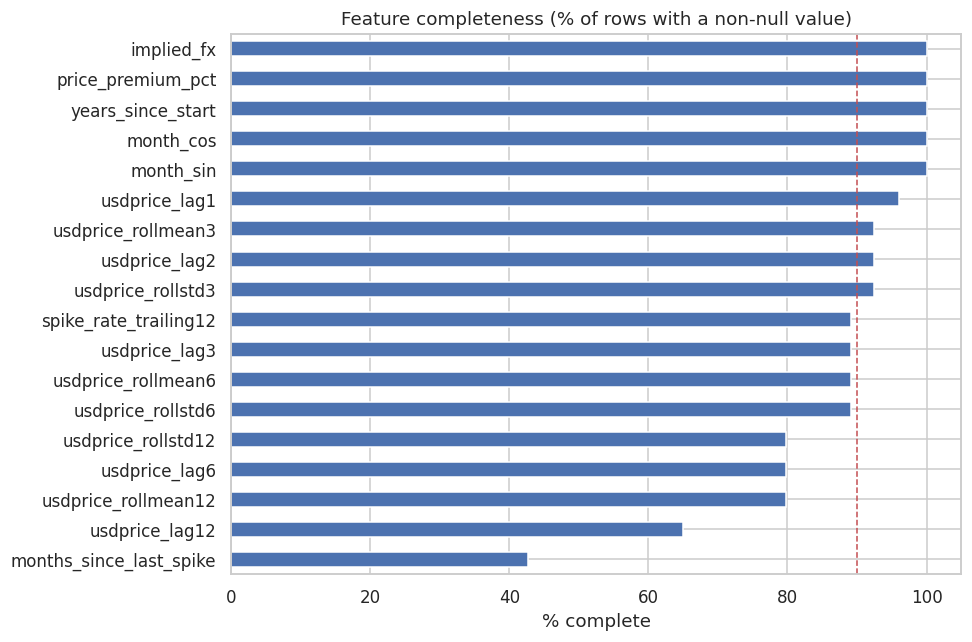

In [8]:
feature_cols = [
    'usdprice_lag1', 'usdprice_lag2', 'usdprice_lag3', 'usdprice_lag6', 'usdprice_lag12',
    'usdprice_rollmean3', 'usdprice_rollstd3', 'usdprice_rollmean6', 'usdprice_rollstd6',
    'usdprice_rollmean12', 'usdprice_rollstd12',
    'spike_rate_trailing12', 'months_since_last_spike',
    'month_sin', 'month_cos', 'years_since_start',
    'price_premium_pct', 'implied_fx',
]

completeness = (1 - df[feature_cols].isna().mean()) * 100
completeness = completeness.sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
completeness.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Feature completeness (% of rows with a non-null value)')
ax.set_xlabel('% complete')
ax.axvline(90, color='#C44E52', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


As expected, longer-lag and longer-window features (`usdprice_lag12`, `usdprice_rollmean12`,
`spike_rate_trailing12`) are less complete, since they require a full year of prior history for that
specific series — new or short-lived market/commodity series simply don't have that yet. Models trained
downstream will need to either use a feature subset with better coverage, or accept a smaller (but still
substantial) training set when using the full feature list.


In [9]:
complete_rows = df.dropna(subset=feature_cols + ['target_next_usdprice'])
print(f'Rows with every engineered feature AND a valid target: {len(complete_rows):,} of {len(df):,} '
      f'({len(complete_rows) / len(df) * 100:.1f}%)')


Rows with every engineered feature AND a valid target: 20,849 of 51,071 (40.8%)


## 8.9 Sanity check — do the engineered features actually relate to the target?

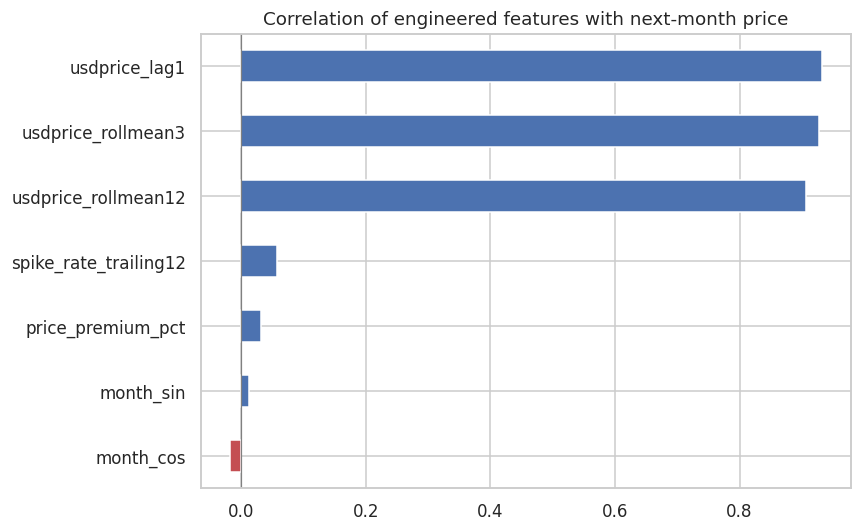

In [10]:
check_cols = ['usdprice_lag1', 'usdprice_rollmean3', 'usdprice_rollmean12', 'price_premium_pct',
              'spike_rate_trailing12', 'month_sin', 'month_cos', 'target_next_usdprice']
corr = complete_rows[check_cols].corr()['target_next_usdprice'].drop('target_next_usdprice').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', ax=ax, color=['#C44E52' if v < 0 else '#4C72B0' for v in corr.values])
ax.set_title('Correlation of engineered features with next-month price')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()


`usdprice_lag1` and the rolling means correlate strongly with next month's price, as expected — recent
price level is the dominant signal, which is exactly why the ARIMA/baseline models in `06`/`07` already do
reasonably well using price history alone. The smaller, non-price features (seasonal encoding, spike
history, regional premium) carry weaker but real linear signal — their value is more likely to show up as
*interactions* (e.g. "high recent spike rate AND lean season") that a tree-based or other non-linear model
in `09 MACHINE LEARNING FORECASTING` can exploit better than a simple correlation can show.


## 8.10 Save the feature matrix

In [11]:
out_cols = (
    ['date', 'admin1', 'admin2', 'market', 'commodity', 'commodity_unit', 'unit', 'pricetype',
     'category', 'usdprice', 'price', 'implied_fx', 'is_spike', 'is_drop', 'pct_change', 'pct_change_z']
    + feature_cols
    + ['target_next_usdprice', 'target_next_pct_change', 'target_next_is_spike']
)
features_out = df[out_cols].copy()
features_out.to_csv('../data/eth_food_prices_features.csv', index=False)
print(f'Saved {len(features_out):,} rows x {features_out.shape[1]} columns -> ../data/eth_food_prices_features.csv')


Saved 51,071 rows x 37 columns -> ../data/eth_food_prices_features.csv


---
## Summary

- Built a **leakage-safe** feature matrix at market × commodity_unit × month granularity: lags (1–12
  months), rolling mean/std (3/6/12 months), trailing spike rate, months-since-last-spike, cyclical month
  encoding, a linear year trend, and a market's price premium relative to the national median for the same
  commodity and month.
- Prepared two forward-looking targets: `target_next_usdprice` (and `_pct_change`) for regression-style
  forecasting, and `target_next_is_spike` for spike classification.
- Feature completeness drops for longer lag/rolling windows, as expected — the exact share of rows with
  every engineered feature and a valid target is reported in §8.8 above, and that subset is what
  `09 MACHINE LEARNING FORECASTING` and `10 SPIKE CLASSIFICATION` should train on.
- Output: `../data/eth_food_prices_features.csv`.
